In [1]:
pwd

'/Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper_DropBox/version4_copyof_version3_March2025/scripts_data_for_beh_paper/code/Fig_4d_S6acd_ICC_covariance'

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os,sys
import matplotlib.pyplot as plt
path_to_add = os.path.abspath('../')
print('path_to_add:',path_to_add)
sys.path.append(path_to_add)
from func_fix_curvefit_params import *
from general_utility_functions import *

path_to_add: /Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper_DropBox/version4_copyof_version3_March2025/scripts_data_for_beh_paper/code


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=14) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

color_plots = 'tab:red' # or tab:red

In [28]:
root_folder = '../../data/subtlety_data/'

In [37]:
curvefit_ses1 = pd.read_csv(f'{root_folder}/curve_fit_subt_ses1/all_params_1k_subt.csv')#merged_apr_ses1.csv')#('../data/ses1_data/curve_fit_rmse/all_params_1k.csv')
curvefit_ses1

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
0,1.0,0.998083,0.018623,-51.767137,0.354384,0.326204,0.091967,0.175069,0.036553,0.158333,0.035833,False
1,2.0,0.994396,0.030065,-45.061484,0.395356,0.379090,0.106477,0.092967,0.003165,0.070833,0.000000,False
2,3.0,0.991012,0.035994,-42.541465,0.496416,0.436420,0.131643,0.291980,0.163815,0.279167,0.151667,False
3,4.0,0.990862,0.036692,-42.272749,0.353184,0.288929,0.114098,0.322398,0.147745,0.298333,0.145833,False
4,5.0,0.976299,0.064073,-34.468260,0.537650,0.506901,0.093353,0.165036,0.036492,0.162500,0.030833,False
...,...,...,...,...,...,...,...,...,...,...,...,...
307,340.0,0.995635,0.028163,-45.976544,0.466990,0.443179,0.085198,0.217295,0.123770,0.214545,0.122500,False
308,341.0,0.932110,0.097494,-28.591477,0.415892,0.240604,0.126042,0.422647,0.126212,0.405833,0.121667,False
309,342.0,0.975376,0.053088,-37.101135,0.482088,0.387694,0.188805,0.375315,0.270528,0.345833,0.245833,False
310,343.0,0.989817,0.043360,-39.935129,0.456643,0.389452,0.102018,0.271140,0.046086,0.263333,0.042727,False


In [38]:
curvefit_ses1.loc[curvefit_ses1['flipped']].shape

(0, 12)

In [39]:
bad_rows = (np.isnan(curvefit_ses1['obj_center'])) | \
      (np.isinf(curvefit_ses1['obj_center'])) | \
    (curvefit_ses1['obj_center']<0)
curvefit_ses1.loc[bad_rows,:] # has bad subs

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
13,15.0,0.907114,0.103089,-27.810296,0.534505,NaN,0.201028,0.543434,0.218639,0.525000,0.193333,False
39,43.0,0.874909,0.113754,-26.431992,0.408599,NaN,0.221992,0.579153,0.144244,0.531667,0.121667,False
88,100.0,0.981739,0.053964,-36.872079,0.423466,NaN,0.127252,0.526937,0.181588,0.516364,0.178333,False
117,132.0,0.988484,0.044332,-39.624762,0.470592,NaN,0.108652,0.527985,0.183901,0.524167,0.181667,False
124,139.0,0.990811,0.040039,-41.050748,0.375244,NaN,0.059265,0.503770,0.250840,0.503333,0.250833,False
129,146.0,0.979431,0.057878,-35.891859,0.525861,NaN,0.084023,0.553146,0.110361,0.552500,0.109167,False
137,154.0,0.984955,0.049049,-38.209221,0.388454,-0.054971,0.084176,0.502281,0.015341,0.497500,0.015000,False
139,156.0,0.993094,0.034272,-43.228128,0.357062,NaN,0.075175,0.569330,0.026745,0.565833,0.026667,False
173,193.0,0.940653,0.088831,-29.894283,0.447231,NaN,0.159722,0.657455,0.209443,0.649091,0.205000,False
207,229.0,0.989475,0.043020,-40.045226,0.338155,NaN,0.109512,0.580672,0.021820,0.562500,0.020833,False


In [40]:
curvefit_ses1 = fix_obj_center(curvefit_ses1)
curvefit_ses1.loc[bad_rows,:]

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
13,15.0,0.907114,0.103089,-27.810296,0.534505,0.0,0.201028,0.543434,0.218639,0.525000,0.193333,False
39,43.0,0.874909,0.113754,-26.431992,0.408599,0.0,0.221992,0.579153,0.144244,0.531667,0.121667,False
88,100.0,0.981739,0.053964,-36.872079,0.423466,0.0,0.127252,0.526937,0.181588,0.516364,0.178333,False
117,132.0,0.988484,0.044332,-39.624762,0.470592,0.0,0.108652,0.527985,0.183901,0.524167,0.181667,False
124,139.0,0.990811,0.040039,-41.050748,0.375244,0.0,0.059265,0.503770,0.250840,0.503333,0.250833,False
129,146.0,0.979431,0.057878,-35.891859,0.525861,0.0,0.084023,0.553146,0.110361,0.552500,0.109167,False
137,154.0,0.984955,0.049049,-38.209221,0.388454,0.0,0.084176,0.502281,0.015341,0.497500,0.015000,False
139,156.0,0.993094,0.034272,-43.228128,0.357062,0.0,0.075175,0.569330,0.026745,0.565833,0.026667,False
173,193.0,0.940653,0.088831,-29.894283,0.447231,0.0,0.159722,0.657455,0.209443,0.649091,0.205000,False
207,229.0,0.989475,0.043020,-40.045226,0.338155,0.0,0.109512,0.580672,0.021820,0.562500,0.020833,False


In [42]:
curvefit_ses1.loc[bad_rows,:].shape

(11, 12)

In [43]:
curvefit_ses1.shape

(312, 12)

In [44]:
bad_rows = (np.isnan(curvefit_ses1['obj_center'])) | \
      (np.isinf(curvefit_ses1['obj_center'])) | \
    (curvefit_ses1['obj_center']<0)
curvefit_ses1.loc[bad_rows,:] # bad subs bc of obj_center removed

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped


In [45]:
curvefit_ses1.shape

(312, 12)

In [46]:
curvefit_ses2 =  pd.read_csv(f'{root_folder}/curve_fit_subt_ses2/all_params_1k_subt.csv')
bad_rows = (np.isnan(curvefit_ses2['obj_center'])) | \
      (np.isinf(curvefit_ses2['obj_center'])) | \
    (curvefit_ses2['obj_center']<0)
curvefit_ses2.loc[bad_rows,:] # bad subs from ses2 removed

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
10,15.0,0.594764,0.190694,-19.199227,0.313610,NaN,0.271394,0.582935,0.200760,0.507500,0.177500,False
29,41.0,0.936395,0.094287,-29.059708,0.430071,NaN,0.143945,0.644136,0.129539,0.632500,0.125000,False
97,146.0,0.963045,0.070438,-33.142256,0.543616,NaN,0.136717,0.561260,0.116657,0.555000,0.105000,False
113,170.0,0.945719,0.088534,-29.941214,0.329023,NaN,0.064599,0.587211,0.052511,0.585000,0.052500,False
131,193.0,0.870836,0.120979,-25.569905,0.220287,NaN,0.137616,0.676697,0.207980,0.653333,0.207500,False
141,206.0,0.940303,0.091834,-29.428751,0.324354,NaN,0.052660,0.561717,0.020001,0.560833,0.020000,False
162,229.0,0.873489,0.128357,-24.741149,0.357200,NaN,0.112038,0.722521,0.082322,0.714444,0.081667,False
196,276.0,0.981602,0.055024,-36.599857,0.398508,NaN,0.098273,0.542320,0.010167,0.534545,0.009167,False
212,303.0,0.963546,0.074767,-32.307370,0.367953,NaN,0.130412,0.554586,0.091282,0.533333,0.088333,False
227,324.0,0.962729,0.077298,-31.841311,0.315902,NaN,0.067468,0.537583,0.003352,0.533333,0.003333,False


In [47]:
curvefit_ses2.loc[curvefit_ses2['flipped']].shape

(0, 12)

In [48]:
curvefit_ses2 = fix_obj_center(curvefit_ses2)
curvefit_ses2.loc[bad_rows,:] # bad subs from ses2 removed

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
10,15.0,0.594764,0.190694,-19.199227,0.313610,0.0,0.271394,0.582935,0.200760,0.507500,0.177500,False
29,41.0,0.936395,0.094287,-29.059708,0.430071,0.0,0.143945,0.644136,0.129539,0.632500,0.125000,False
97,146.0,0.963045,0.070438,-33.142256,0.543616,0.0,0.136717,0.561260,0.116657,0.555000,0.105000,False
113,170.0,0.945719,0.088534,-29.941214,0.329023,0.0,0.064599,0.587211,0.052511,0.585000,0.052500,False
131,193.0,0.870836,0.120979,-25.569905,0.220287,0.0,0.137616,0.676697,0.207980,0.653333,0.207500,False
141,206.0,0.940303,0.091834,-29.428751,0.324354,0.0,0.052660,0.561717,0.020001,0.560833,0.020000,False
162,229.0,0.873489,0.128357,-24.741149,0.357200,0.0,0.112038,0.722521,0.082322,0.714444,0.081667,False
196,276.0,0.981602,0.055024,-36.599857,0.398508,0.0,0.098273,0.542320,0.010167,0.534545,0.009167,False
212,303.0,0.963546,0.074767,-32.307370,0.367953,0.0,0.130412,0.554586,0.091282,0.533333,0.088333,False
227,324.0,0.962729,0.077298,-31.841311,0.315902,0.0,0.067468,0.537583,0.003352,0.533333,0.003333,False


In [49]:
curvefit_ses2.loc[bad_rows,:].shape

(10, 12)

In [50]:
curvefit_ses2.shape

(240, 12)

In [ ]:
bad_rows = (np.isnan(curvefit_ses2['obj_center'])) | \
      (np.isinf(curvefit_ses2['obj_center'])) | \
    (curvefit_ses2['obj_center']<0)

curvefit_ses2.loc[bad_rows,:] # bad subs bc of obj_center removed

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped


In [8]:
curvefit_ses1 = add_new_params(curvefit_ses1)
curvefit_ses1.loc[curvefit_ses1['range']<0,:] # no neg amp subs

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [9]:
curvefit_ses2 = add_new_params(curvefit_ses2)
curvefit_ses2.loc[curvefit_ses2['range']<0,:] # no neg amp subs

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [10]:
curvefit_ses1.rename(columns={'obj_center':'PSE'},inplace=True) # rename obj_center
curvefit_ses2.rename(columns={'obj_center':'PSE'},inplace=True)

In [11]:
return_minmax(curvefit_ses1,'PSE')
return_minmax(curvefit_ses1,'range')
return_minmax(curvefit_ses1,'bias')

return_minmax(curvefit_ses2,'PSE')
return_minmax(curvefit_ses2,'range')
return_minmax(curvefit_ses2,'bias')

PSE: min=0.00, max=0.53
range: min=0.13, max=1.00
bias: min=0.06, max=1.00
PSE: min=0.00, max=0.59
range: min=0.12, max=1.00
bias: min=0.07, max=1.00


In [12]:
curvefit_ses1.shape, curvefit_ses2.shape

((312, 14), (240, 14))

In [13]:
cmap = 'BrBG'#'RdBu_r'

In [14]:
# cols = ['PSE','range','bias','sigma']
cols = ['PSE','range','bias']

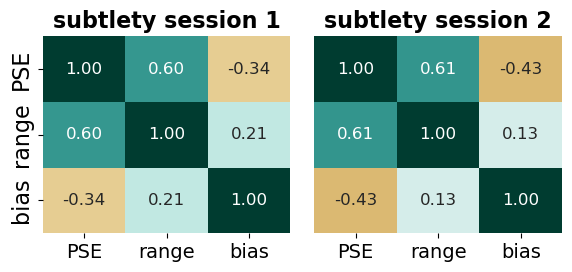

In [15]:
fig,axs = plt.subplots(nrows=1,ncols = 2, figsize=(6,3))

ax = axs[0]
sns.heatmap(curvefit_ses1.loc[:,cols].corr(),vmin=-1,vmax=1,annot=True,cbar=False,cmap=cmap,ax=ax, fmt = '.2f',annot_kws={"size": 12})
ax.set_title('subtlety session 1',fontweight='bold')

ax = axs[1]
sns.heatmap(curvefit_ses2.loc[:,cols].corr(),vmin=-1,vmax=1,annot=True,cbar=False,cmap=cmap,ax=ax, fmt = '.2f',annot_kws={"size": 12})
ax.set_title('subtlety session 2',fontweight='bold')
ax.set_yticks([])

plt.tight_layout()
plt.savefig('../../results/subtlety/curvefit_covar_allcols_subtlety.png', dpi=300, bbox_inches='tight')

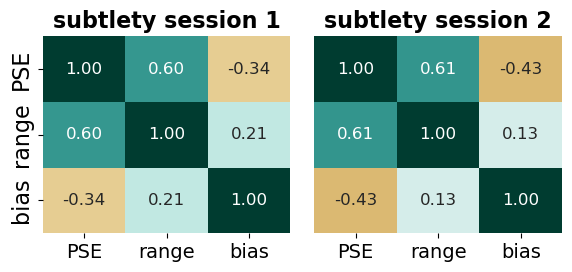

In [16]:
fig,axs = plt.subplots(nrows=1,ncols = 2, figsize=(6,3))

ax = axs[0]
sns.heatmap(curvefit_ses1.loc[:,cols].corr(),vmin=-1,vmax=1,annot=True,cbar=False,cmap=cmap,ax=ax, fmt = '.2f',annot_kws={"size": 12})
ax.set_title('subtlety session 1',fontweight='bold')

ax = axs[1]
sns.heatmap(curvefit_ses2.loc[:,cols].corr(),vmin=-1,vmax=1,annot=True,cbar=False,cmap=cmap,ax=ax, fmt = '.2f',annot_kws={"size": 12})
ax.set_title('subtlety session 2',fontweight='bold')
ax.set_yticks([])

plt.tight_layout()
plt.savefig('../../results/subtlety/curvefit_covar_allcols_subtlety.png', dpi=300, bbox_inches='tight')

## Merge dfs

In [17]:
bothsess = curvefit_ses1.loc[:,['subID']+cols].merge(curvefit_ses2.loc[:,['subID']+cols],how='inner',on='subID',suffixes = ['_ses1','_ses2'])
bothsess

,subID,PSE_ses1,range_ses1,bias_ses1,PSE_ses2,range_ses2,bias_ses2
0,2.0,0.379090,0.903868,0.967075,0.379686,0.726720,0.829038
1,4.0,0.288929,0.529857,0.685745,0.375676,0.439713,0.666962
2,5.0,0.506901,0.798472,0.818923,0.385977,0.476307,0.736661
3,6.0,0.187152,0.701900,0.994459,0.326023,0.326753,0.633382
4,7.0,0.419016,0.751468,0.759523,0.433843,0.640942,0.805572
...,...,...,...,...,...,...,...
235,340.0,0.443179,0.658936,0.637108,0.389330,0.765904,0.718131
236,341.0,0.240604,0.451141,0.770046,0.056328,0.312857,0.709333
237,342.0,0.387694,0.354157,0.581124,0.344159,0.326620,0.615692
238,343.0,0.389452,0.682775,0.854723,0.377460,0.998957,0.988611


# Evaluate differences

In [18]:
# from general_functions import *
from scipy import stats

In [19]:
def get_p(p):
    if p < .001:
        txt = '***'
    elif p < .01:
        txt = '**'
    elif p < .05:
        txt = '*'
    return txt

In [20]:
lims = {'PSE':[-.05,0.6],'range':[0,1.2],'bias':[0,1.2]} #{'PSE':[0,0.6],'range':[0,1],'bias':[0,1]}

PSE,p=0.093, MD:0.01
range,p=0.008, MD:0.02
bias,p=0.395, MD:0.01


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_41504/8996925.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['ses1','ses2'])
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_41504/8996925.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),fontsize=16)
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_41504/8996925.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['ses1','ses2'])
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_41504/8996925.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels()

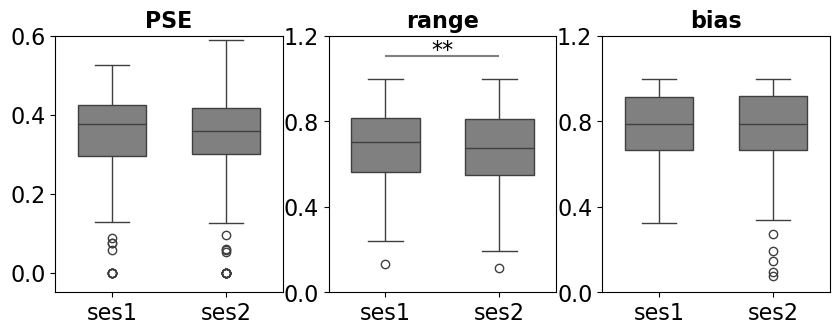

In [25]:
fig,axs = plt.subplots(figsize = (10,3.33),nrows=1,ncols=3)
for i,param in enumerate(['PSE','range','bias']):
    ax = axs[i]
    sns.boxplot(data=bothsess[[param+'_ses1',param+'_ses2']],color='grey',ax=ax, width=.6)
    ax.set_title(param,fontweight='bold')
    ax.set_xticklabels(['ses1','ses2'])
    ax.set_ylim(lims[param][0],lims[param][1])
    ax.set_xlim(-.5,1.5)
    ax.set_xticklabels(ax.get_xticklabels(),fontsize=16)
    _,p=stats.ttest_rel(bothsess[param+'_ses1'],bothsess[param+'_ses2'])
    if p < .05:
        ax.hlines(ax.get_ylim()[1]*.92,0,1,color='grey')
        ax.annotate(get_p(p),xy=(.5,.99),xycoords="axes fraction",ha='center',va='top')
    if i == 0:
        ax.set_yticks([0,0.2,0.4,0.6])
    if i == 1:
        ax.set_yticks([0,0.4,.8,1.2])
    if i==2:
        ax.set_yticks([0,0.4,0.8,1.2])
    # print(param,p)
    MD = (bothsess[param+'_ses1']-bothsess[param+'_ses2']).mean()
    print(f'{param},p={p:.3f}, MD:{MD:.2f}')
plt.savefig('../../results/subtlety/curve_params_ses1_vs_2_boxplot.jpg', dpi=300, bbox_inches='tight')

# Plot ICC

# ICC

In [26]:
import pingouin as pg

bothsess_long = curvefit_ses1.merge(curvefit_ses2,how='inner',on='subID',suffixes = ['_ses1','_ses2'])

curvefit_ses1['sesID'] = 'ses_1'
curvefit_ses2['sesID'] = 'ses_2'
# Identify common subjects across both sessions
common_subjects = set(curvefit_ses2['subID']).intersection(curvefit_ses2['subID'])

# Filter dataframes to keep only common subjects
curvefit_ses1 = curvefit_ses1[curvefit_ses1['subID'].isin(common_subjects)]
curvefit_ses2 = curvefit_ses2[curvefit_ses2['subID'].isin(common_subjects)]

# Concatenate filtered dataframes vertically
bothsess_long = pd.concat([curvefit_ses1, curvefit_ses2], ignore_index=True)
bothsess_long.head()

colnames = ['PSE','range','bias','sigma','subj_center','lb','ub']

save_icc = {}
# Calculate ICC for each parameter
for param in colnames:
    print(param)
    if param == 'subj_center':
        param = 'center'
    elif param == 'lb':
        param = 'bias_xmin'
    elif param == 'ub':
        param = 'bias_xmax'
    icc = pg.intraclass_corr(data=bothsess_long, targets = 'subID', raters = 'sesID', ratings = param, nan_policy='omit')
    # printing results for ICC 1
    print(f"ICC2 for {param}: {icc.iloc[1, 2]:.3f},ICC2k for {param}: {icc.iloc[4, 2]:.3f}")
    save_icc[param] = [icc.iloc[1, 2], icc.iloc[1, 6]]

PSE
ICC2 for PSE: 0.702,ICC2k for PSE: 0.825
range
ICC2 for range: 0.743,ICC2k for range: 0.853
bias
ICC2 for bias: 0.534,ICC2k for bias: 0.696
sigma
ICC2 for sigma: 0.523,ICC2k for sigma: 0.687
subj_center
ICC2 for center: 0.378,ICC2k for center: 0.548
lb
ICC2 for bias_xmin: 0.708,ICC2k for bias_xmin: 0.829
ub
ICC2 for bias_xmax: 0.721,ICC2k for bias_xmax: 0.838


/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.3.12, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# Plots

In [27]:
def get_p_markers(p):
    if p < .001:
        return "***"
    elif p < .01:
        return f"**"
    elif p < .05:
        return f"*"

ticks_all = {'PSE':[0,0.3,0.6],'range':[0,0.5,1],'bias':[0,0.5,1]}

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

color_plots = 'tab:red' # or tab:red

In [29]:
save_icc["lb"] = save_icc.pop("bias_xmin")
save_icc["ub"] = save_icc.pop("bias_xmax")
save_icc

{'PSE': [np.float64(0.7016033178900908), np.float64(1.435245145925028e-37)],
 'range': [np.float64(0.7429982251810355), np.float64(1.0207968965760667e-44)],
 'bias': [np.float64(0.5337191329841083), np.float64(2.003532686416866e-19)],
 'sigma': [np.float64(0.5231369600257385), np.float64(1.3495480647904458e-18)],
 'center': [np.float64(0.37759784744309394),
  np.float64(6.567322630127009e-10)],
 'lb': [np.float64(0.707902600399313), np.float64(1.0683201434967545e-38)],
 'ub': [np.float64(0.7213738645240574), np.float64(7.4375132813608e-41)]}

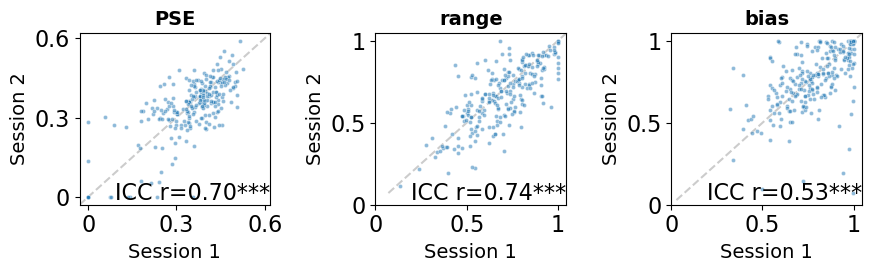

In [31]:
fig, axs = plt.subplots(nrows=1, ncols=len(cols), figsize=(3*len(cols),3))  # Adjusting subplot size to make plots square
for i, item in enumerate(cols):
    ax = axs[i] #axs[i]
    sns.scatterplot(data=bothsess, x=item + '_ses1', y=item + '_ses2', ax=ax, color = 'tab:blue',alpha=0.5, marker = '.')
    # ax.set_aspect('equal')  # Ensures same scale on x and y axes
    # Adding a diagonal line from the minimum to maximum values
    limits = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(limits, limits, 'k--', zorder=0, alpha = .2)  # 'k--' specifies a black dotted line
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ticks = ticks_all[item] #np.arange(limits[0],limits[1]*1.01,(limits[1]-limits[0])/3)
    ticks = ticks_all[item]#[np.round(i,1) for i in ticks]

    ticklabels = []
    for t in ticks:
        ticklabels.append(str(t))
    ax.set_xticks(ticks,ticklabels)
    ax.set_yticks(ticks,ticklabels)
    x,y =  bothsess[item + '_ses1'],bothsess[item + '_ses2']
    rows = ~(np.isnan(x)) & ~(np.isnan(y)) & ~(np.isinf(x)) & ~(np.isinf(y))
    x = x[rows]
    y = y[rows]
    r_p,p_p = stats.pearsonr(x,y)
    r_s,p_s = stats.spearmanr(x,y)
    # ax.annotate(f'ICC r={r_p:.2f}{get_p_markers(p_p)}', xy = (.05,.95),va='top',xycoords='axes fraction')
    ax.annotate(f'ICC r={save_icc[item][0]:.2f}{get_p_markers(save_icc[item][1])}', xy = (1,0),va='bottom',ha='right',xycoords='axes fraction')
    ax.set_title(item, fontweight='bold',fontsize=14)  #item,fontweight='bold')

    # ax.set_title(meaningful_names[item], fontweight='bold') #item,fontweight='bold')
    ax.set_xlabel('Session 1',fontsize=14)
    ax.set_ylabel('Session 2',fontsize=14)

plt.tight_layout()
plt.savefig('../../results/subtlety/ICC_subtlety.png',dpi=300,bbox_inches='tight')

# supp rows

In [32]:
curvefit_ses1_extra = curvefit_ses1.drop(columns=['bias_lower','bias_upper']).rename(columns={'bias_xmin':'lb','bias_xmax':'ub'})
curvefit_ses2_extra = curvefit_ses2.drop(columns=['bias_lower','bias_upper']).rename(columns={'bias_xmin':'lb','bias_xmax':'ub'})

In [33]:
supp_cols = ['sigma','center','lb','ub']#,'aic']

In [34]:
bothsess_extra = curvefit_ses1_extra.loc[:,['subID']+supp_cols].merge(curvefit_ses2_extra.loc[:,['subID']+supp_cols],how='inner',on='subID',suffixes = ['_ses1','_ses2'])
bothsess_extra

,subID,sigma_ses1,center_ses1,lb_ses1,ub_ses1,sigma_ses2,center_ses2,lb_ses2,ub_ses2
0,2.0,0.106477,0.395356,0.092967,0.003165,0.132783,0.437272,0.226559,0.046721
1,4.0,0.114098,0.353184,0.322398,0.147745,0.138347,0.493091,0.373690,0.186597
2,5.0,0.093353,0.537650,0.165036,0.036492,0.093328,0.492211,0.385784,0.137909
3,6.0,0.121123,0.252783,0.296448,0.001652,0.130284,0.475595,0.426422,0.246824
4,7.0,0.087977,0.448519,0.188766,0.059766,0.083456,0.492990,0.289247,0.069811
...,...,...,...,...,...,...,...,...,...
235,340.0,0.085198,0.466990,0.217295,0.123770,0.088312,0.411307,0.168112,0.065985
236,341.0,0.126042,0.415892,0.422647,0.126212,0.146806,0.342403,0.487413,0.199730
237,342.0,0.188805,0.482088,0.375315,0.270528,0.217861,0.538108,0.414595,0.258785
238,343.0,0.102018,0.456643,0.271140,0.046086,0.054893,0.377460,0.001031,0.000012


In [35]:
ticks_all = {'sigma':[0,0.15,0.3],'center':[0.2,0.4,0.6],'lb':[0,0.4,0.8],'ub':[0,0.15,0.3]}

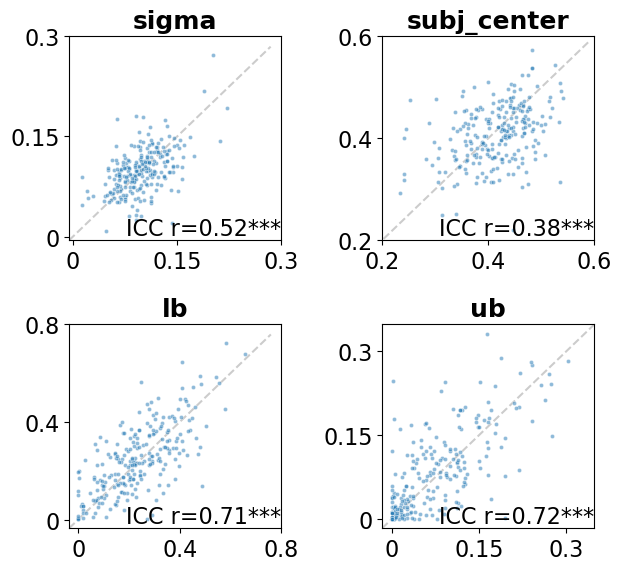

In [36]:
# fig, axs = plt.subplots(nrows=1, ncols=len(supp_cols), figsize=(3*len(supp_cols),3))  # Adjusting subplot size to make plots square
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(3.25*int(len(supp_cols)/2),3*int(len(supp_cols)/2)))  # Adjusting subplot size to make plots square
for i, item in enumerate(supp_cols):
    # ax = axs[i] #axs[i]
    r = int(np.floor(i/2))
    c = i%2
    ax = axs[r,c]
    sns.scatterplot(data=bothsess_extra, x=item + '_ses1', y=item + '_ses2', ax=ax, color = 'tab:blue',alpha=0.5, marker = '.')
    # Adding a diagonal line from the minimum to maximum values
    limits = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(limits, limits, 'k--', zorder=0, alpha = .2)  # 'k--' specifies a black dotted line
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    
    ticks = ticks_all[item] #np.arange(limits[0],limits[1]*1.01,(limits[1]-limits[0])/3)
    ticklabels = []
    for t in ticks:
        ticklabels.append(str(t))
    ax.set_xticks(ticks,ticklabels)
    ax.set_yticks(ticks,ticklabels)

    x,y =  bothsess_extra[item + '_ses1'],bothsess_extra[item + '_ses2']
    rows = ~(np.isnan(x)) & ~(np.isnan(y)) & ~(np.isinf(x)) & ~(np.isinf(y))
    x = x[rows]
    y = y[rows]
    ax.annotate(f'ICC r={save_icc[item][0]:.2f}{get_p_markers(save_icc[item][1])}', xy = (1,0),ha = 'right', va='bottom',xycoords='axes fraction')
    
    if item == 'center':
        item = 'subj_center'
    ax.set_title(item, fontweight='bold',fontsize=18) #item,fontweight='bold')
    
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../../results/subtlety/ICC_subtlety_extra.png',dpi=300,bbox_inches='tight')

In [37]:
curvefit_ses1.rename(columns = {'center':'subj_center', 'bias_xmin': 'lb', \
    'bias_xmax': 'ub'},inplace=True)
curvefit_ses1.columns

Index(['subID', 'r_squared', 'nrmse', 'aic', 'subj_center', 'PSE', 'sigma',
       'lb', 'ub', 'bias_lower', 'bias_upper', 'flipped', 'range', 'bias',
       'sesID'],
      dtype='object')

In [38]:
curvefit_ses2.rename(columns = {'center':'subj_center', 'bias_xmin': 'lb', \
    'bias_xmax': 'ub'},inplace=True)
curvefit_ses2.columns

Index(['subID', 'r_squared', 'nrmse', 'aic', 'subj_center', 'PSE', 'sigma',
       'lb', 'ub', 'bias_lower', 'bias_upper', 'flipped', 'range', 'bias',
       'sesID'],
      dtype='object')

In [39]:
cols_subt = ['PSE','range','bias', 'lb','ub', 
    'sigma','subj_center'] # cols+supp_cols


In [40]:
cols_subt_lbl  = [i if i!='subj_center' else 'subj_\ncenter' for i in cols_subt]

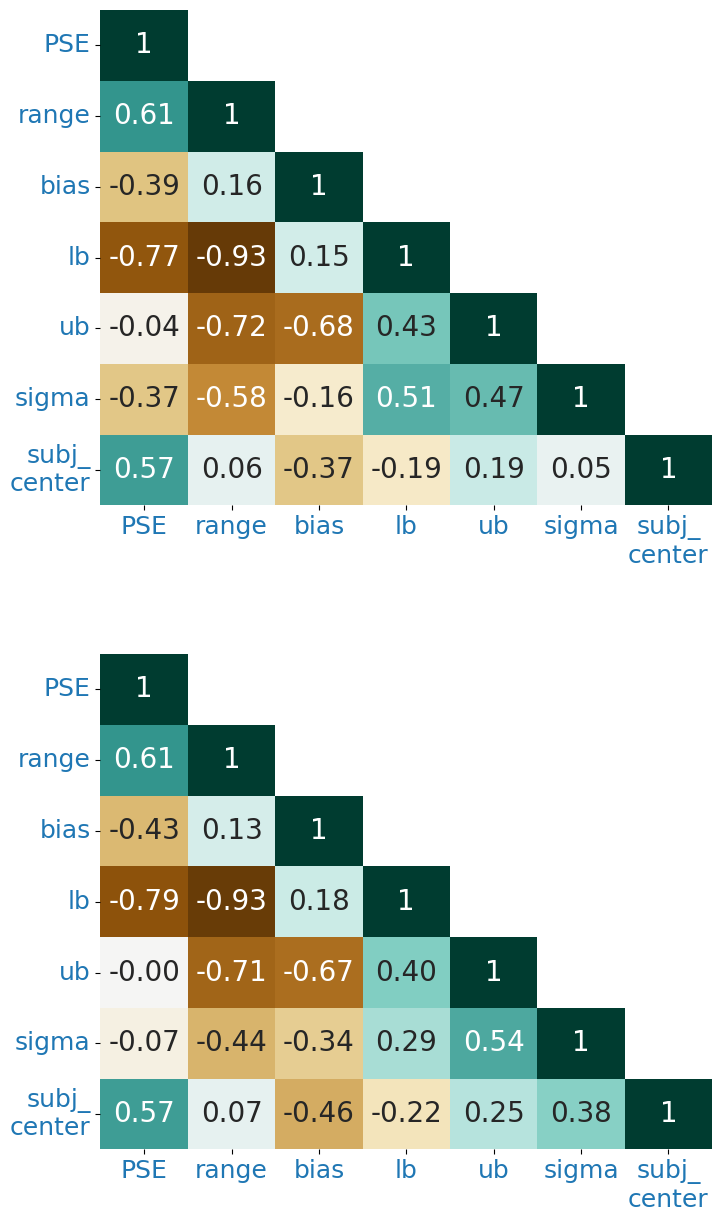

In [60]:
fig,axs = plt.subplots(nrows=2,ncols = 1, figsize=(7.5,12.5))

mask = np.triu(np.ones((len(cols_subt),len(cols_subt)), dtype=bool),k=1)

ax = axs[0]
r_all = curvefit_ses1.loc[:,cols_subt].corr().values
annot = np.array([[f"{val:.2f}" if val <.999 else "1" for val in row] for row in r_all])
sns.heatmap(r_all,vmin=-1,vmax=1,annot=annot,cbar=False,mask=mask,cmap=cmap,ax=ax, fmt = '',annot_kws={"size": 20})
# sns.heatmap(curvefit_ses1.loc[:,cols_subt].corr(),vmin=-1,vmax=1,annot=True,cbar=False,mask=mask,cmap=cmap,ax=ax, fmt = '.2f',annot_kws={"size": 16})
# ax.set_title('Session 1',fontweight='bold', fontsize=26)
ax.set_xticklabels(cols_subt_lbl,rotation=0, fontsize=18, color = 'tab:blue')
ax.set_yticklabels(cols_subt_lbl,rotation=0, fontsize=18, color = 'tab:blue')

ax = axs[1]
r_all = curvefit_ses2.loc[:,cols_subt].corr().values
annot = np.array([[f"{val:.2f}" if val <.999 else "1" for val in row] for row in r_all])
sns.heatmap(r_all,vmin=-1,vmax=1,annot=annot,cbar=False,mask=mask,cmap=cmap,ax=ax, fmt = '',annot_kws={"size": 20})
# sns.heatmap(curvefit_ses2.loc[:,cols_subt].corr(),vmin=-1,vmax=1,annot=True,cbar=False,mask=mask,cmap=cmap,ax=ax, fmt = '.2f',annot_kws={"size": 16})
# ax.set_title('Session 2',fontweight='bold', fontsize=26)
ax.set_xticklabels(cols_subt_lbl,rotation=0, fontsize=18, color = 'tab:blue')
ax.set_yticklabels(cols_subt_lbl,rotation=0, fontsize=18, color = 'tab:blue')
# ax.set_yticks([])

plt.tight_layout()
# plt.suptitle('Social detection task', fontweight = 'bold',fontsize=16)
plt.subplots_adjust(hspace=.3, wspace=0.5)  # Adjust spacing between subplots


plt.savefig('../../results/subtlety/curvefit_covar_allcols_all_subtlety.png', dpi=300, bbox_inches='tight')

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize = (2,6))
sns.heatmap()